**Christine Sako, DATASCI W210, SPRING 2026**

## Loading Data and Confirming Shapes and Dtypes
Key Takeaways:
- The shape of the data is (300, 16)
- The `Date` column should be converted to a datetime


In [98]:
# Importing necessary packages
from IPython.display import display
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Defining GDrive filepath
local_dir = '/content/drive/MyDrive/SPRING 2026/DATASCI 210/Capstone/Data/ADS'

# Loading CSV
ads_df = pd.read_csv(local_dir + '/ad_annotations.csv')

# Printing the shape and dtype head
print("\n")
print(f"`ads_df` shape: {ads_df.shape}")
display(ads_df.dtypes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


`ads_df` shape: (300, 16)


,0
Ad ID,object
Annotator,object
Platform,object
Date,object
Industry,object
Brand,object
Product,object
B2B/B2C,object
Energy (1-5),int64
Tempo,object


###Data Cleaning


Key Goals:
- Drop `Unnamed` row(s)
- Convert `Date` to datetime
- Change the name of the `Notes` column to `video_title`
- Clean/standardize column names

In [99]:
# Dropping Unnamed row(s)
ads_df = ads_df.loc[:, ~ads_df.columns.str.contains('^Unnamed')]

# Converting `Date` to datetime
ads_df['Date'] = pd.to_datetime(ads_df['Date'], errors='coerce')

# Changing the name of the `notes` column to `video_title`
ads_df.rename(columns={'Notes': 'video_title'}, inplace = True)

# Standardizing column names
ads_df.columns = (
    ads_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("/", "_")
    .str.replace("-", "_")
)

# Checking current state
print("Cleaned dataset info:\n")
display(ads_df.info())


Cleaned dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ad_id           300 non-null    object        
 1   annotator       300 non-null    object        
 2   platform        300 non-null    object        
 3   date            300 non-null    datetime64[ns]
 4   industry        300 non-null    object        
 5   brand           300 non-null    object        
 6   product         298 non-null    object        
 7   b2b_b2c         300 non-null    object        
 8   energy_1_5      300 non-null    int64         
 9   tempo           300 non-null    object        
 10  mood            300 non-null    object        
 11  duration_sec    300 non-null    int64         
 12  ad_description  300 non-null    object        
 13  url             300 non-null    object        
 14  video_title     300 non-null    obj

None

###Checking Summaries and Counts for Ad Vibe Features
Key Takeaways:
- `energy_1_5` looks symmetric and balanced
- `tempo` distribution is Medium > Slow > Fast
- `mood` distribution is Positive > Serious > Neutral


In [100]:
# Summarizing statistics for applicable columns:
print("Summary statistics for applicable columns:\n")
display(ads_df.describe())

# Getting counts for `energy_1-5`, `tempo`, and `mood`
print("\n")
print("`energy_1_5` counts:")
display(ads_df['energy_1_5'].value_counts().sort_index())

print("\n")
print("`tempo` counts:")
display(ads_df['tempo'].value_counts())

print("\n")
print("`mood` counts:")
display(ads_df['mood'].value_counts())

Summary statistics for applicable columns:



,date,energy_1_5,duration_sec
count,300,300.000000,300.000000
mean,2026-02-15 12:24:00,3.000000,42.150000
min,2026-02-13 00:00:00,1.000000,15.000000
25%,2026-02-14 00:00:00,2.000000,30.000000
50%,2026-02-16 00:00:00,3.000000,30.000000
75%,2026-02-17 00:00:00,4.000000,60.000000
max,2026-02-17 00:00:00,5.000000,90.000000
std,NaN,0.950268,22.322376




`energy_1_5` counts:


,count
energy_1_5,
1,16
2,73
3,120
4,77
5,14




`tempo` counts:


,count
tempo,
Medium,169
Slow,77
Fast,54




`mood` counts:


,count
mood,
Positive,196
Serious,65
Neutral,39


### Data Distributions Visualizations
Key Takeaways:
- `energy_1_5` looks symmetric and balanced as determined earlier
- 30 second ads dominate `duration_sec`, with the shortest (15) and longest (60) ads being the most infrequent is skewed




`energy_1_5` counts:


,count
energy_1_5,
1,16
2,73
3,120
4,77
5,14


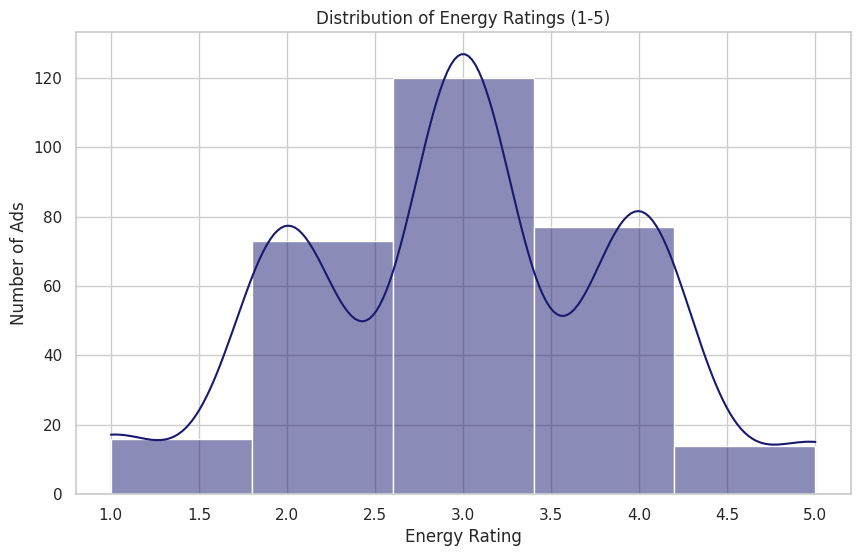



`duration_sec` counts:


,count
duration_sec,
30,152
60,77
15,39
90,32


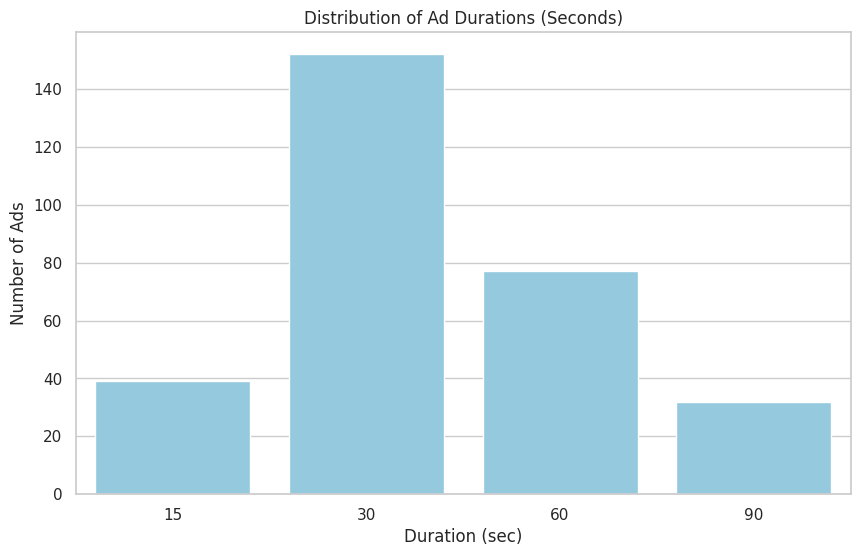

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# Re-displaying value counts for `energy_1_5`
print("\n")
print("`energy_1_5` counts:")
display(ads_df['energy_1_5'].value_counts().sort_index())

# Creating histogram for `energy_1_5`
plt.figure(figsize=(10, 6))
sns.histplot(
    ads_df['energy_1_5'],
    bins = 5,
    color = 'midnightblue',
    kde = True
)
plt.title('Distribution of Energy Ratings (1-5)')
plt.xlabel('Energy Rating')
plt.ylabel('Number of Ads')
plt.show()

# Getting value counts for `duration_sec`
print("\n")
print("`duration_sec` counts:")
display(ads_df['duration_sec'].value_counts())

# Creating histogram for `duration_sec`
print("\n")
plt.figure(figsize = (10, 6))
sns.countplot(
    x = 'duration_sec',
    data = ads_df,
    color = 'skyblue',
    order = [15, 30, 60, 90]
)
plt.title('Distribution of Ad Durations (Seconds)')
plt.xlabel('Duration (sec)')
plt.ylabel('Number of Ads')
plt.show()

## Cross Feature Analyses


### Tempo x Mood
Key Takeaways:
- Medium tempo dominates across all moods
- Fast tempo favors positive mood
- Slow tempo has more serious ads
- Neutral mood is rare overall


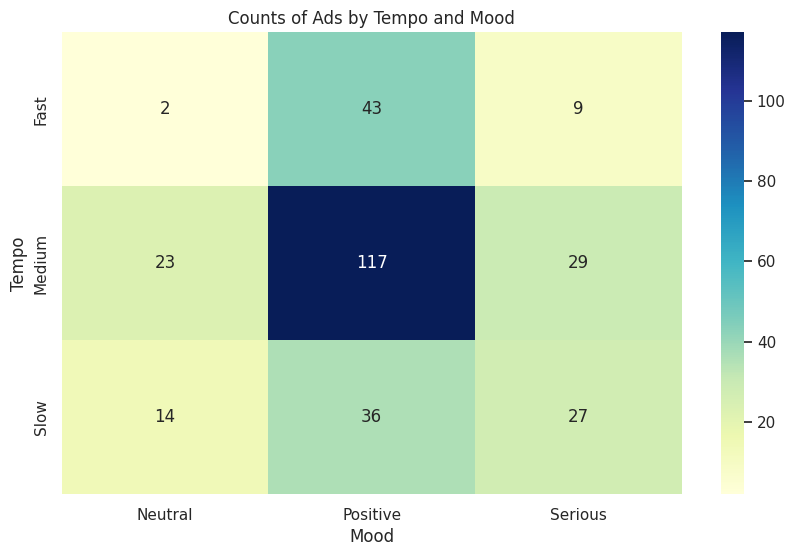

In [102]:
# Creating cross tab of `tempo` and `mood`
tempo_mood = pd.crosstab(ads_df['tempo'], ads_df['mood'])

# Plotting heatmap of crosstab
print("\n")
plt.figure(figsize = (10, 6))
sns.heatmap(
    tempo_mood,
    annot = True,
    fmt = 'd',
    cmap = 'YlGnBu',
    cbar = True
)
plt.title('Counts of Ads by Tempo and Mood')
plt.xlabel('Mood')
plt.ylabel('Tempo')
plt.show()



###Industry x Mood
Key Takeaways:
- **Industry x Mood**
  - Positive mood is the default “go-to” for most industries.
  - Serious ads are more common in Retail, Tech, Healthcare, likely reflecting brand positioning or product type.
  - Neutral ads are generally rare and concentrated in “Other” or F&B.
- **Industry x Tempo**
  - Medium tempo is the “default” pacing across most industries.
  - Fast tempo tends to appear in Tech, Automotive, and consumer-focused industries.
  - Slow tempo is used selectively in Healthcare, F&B, and Other, likely when seriousness or attention is important.
  - Tempo patterns align with expected ad intent (e.g. Fast/Medium for high-energy and attention-grabbing ads. Slow for calm, serious, informative ads)
- **Industry x Energy**
  - Medium energy (3–4) is the “default” across almost all industries.
  - Low-energy ads are mostly in Healthcare and Other, reflecting serious/calm messaging.
  - High-energy ads (5) are rare, concentrated in Entertainment, Tech, and a few Retail ads, likely for high-intensity, attention-grabbing campaigns.
  - This aligns with tempo patterns (industries with low energy also had slower tempos (Healthcare, Other), and high-energy industries like Tech and Entertainment favor faster or medium tempos)

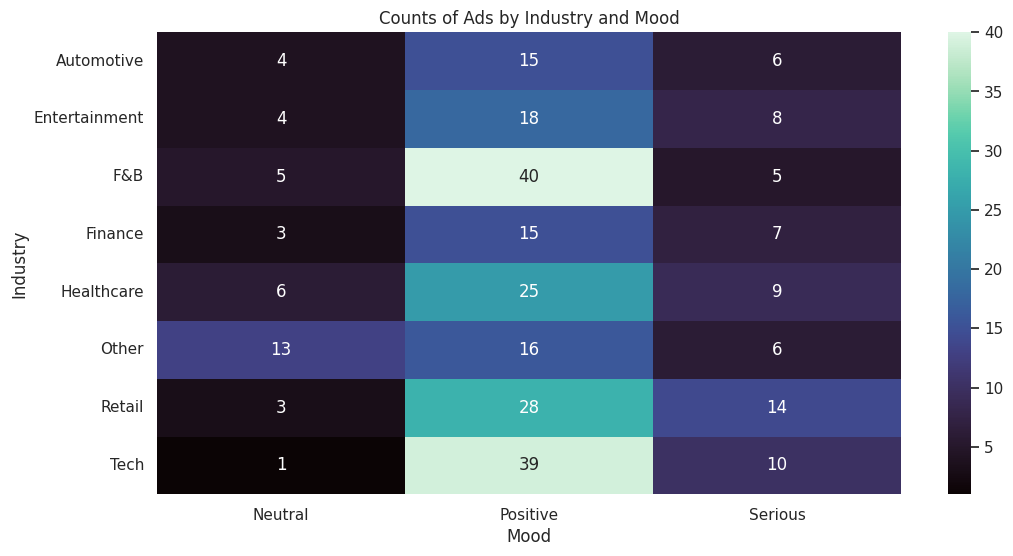

<Figure size 1200x600 with 0 Axes>

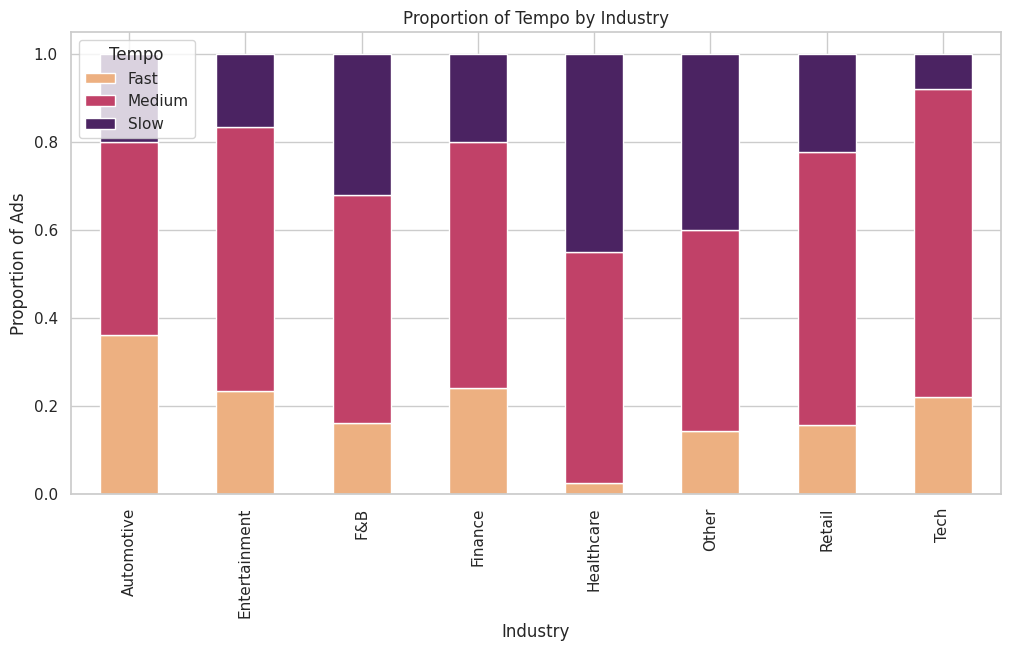

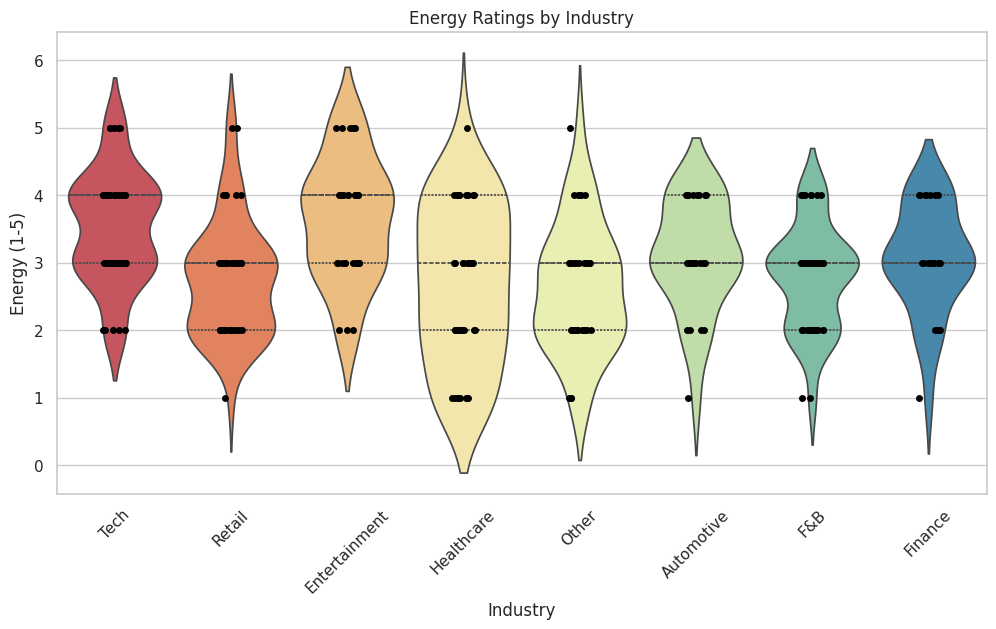

In [103]:
# Creating crosstab of counts of ads by `industry` and `mood`
industry_mood = pd.crosstab(ads_df['industry'], ads_df['mood'])

# Plotting crosstab as a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    industry_mood,
    annot=True,
    fmt='d',
    cmap='mako',
    cbar=True
)
plt.title('Counts of Ads by Industry and Mood')
plt.xlabel('Mood')
plt.ylabel('Industry')
plt.show()


# Creating crosstab of counts of ads by `industry` and `tempo`
industry_tempo = pd.crosstab(ads_df['industry'], ads_df['tempo'])

# Creating proportion of ads by `industry` and `tempo`
plt.figure(figsize = (12,6))
industry_tempo_norm = industry_tempo.div(industry_tempo.sum(axis=1), axis=0)

# Plotting crosstab as proportions
print("\n")
industry_tempo_norm.plot(kind = 'bar', stacked = True, colormap = 'flare', figsize = (12,6))
plt.title('Proportion of Tempo by Industry')
plt.xlabel('Industry')
plt.ylabel('Proportion of Ads')
plt.legend(title = 'Tempo')
plt.show()


# Creating violin plot with strip plot for `industry` vs. `energy_1_5`
print("\n")
plt.figure(figsize = (12, 6))
sns.violinplot(
    x = 'industry',
    y = 'energy_1_5',
    data = ads_df,
    hue = 'industry',
    palette = 'Spectral',
    dodge = False,
    inner = 'quartile'
)
sns.stripplot(
    x = 'industry',
    y = 'energy_1_5',
    data = ads_df,
    color = 'black',
    size = 5,
    jitter = True,
    dodge = False
)
plt.legend([], [], frameon = False)
plt.title('Energy Ratings by Industry')
plt.xlabel('Industry')
plt.ylabel('Energy (1-5)')
plt.xticks(rotation=45)
plt.show()




###Energy x Other Ad Features
Key Takeaways:
- **Energy x Mood:** As expected, positive ads have moderate to higher energy, serious ads have a pretty well distributed spread centered around moderate energy, and neutral ads have lower to moderate energy
- **Energy x Tempo:** As expected, lower ads have lower energy, medium tempo ads have moderate energy, and faster ads have higher energy
- **Energy x Duration:** The spread of energy across duration is relatively centered around moderate energy for 30 and 60 second ads, with an absense of lower energy for 15 second ads, and a higher-energy skewed distribution for 90 second ads


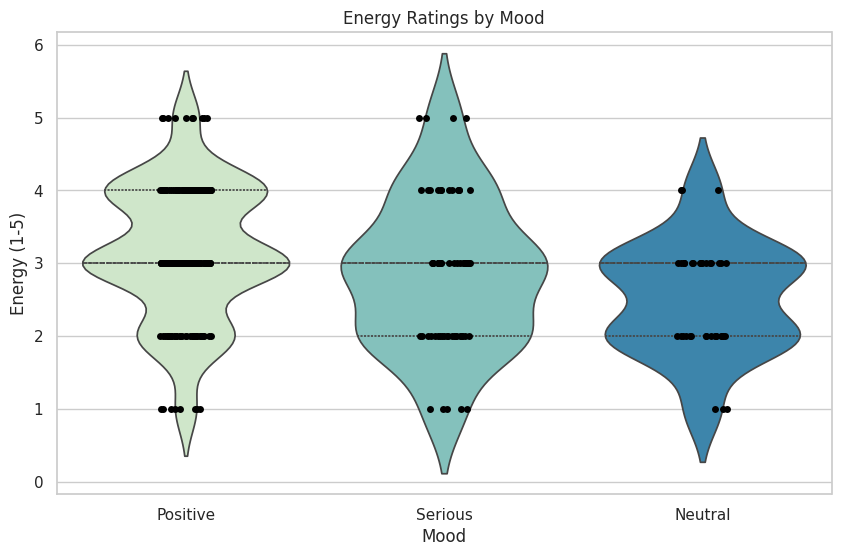

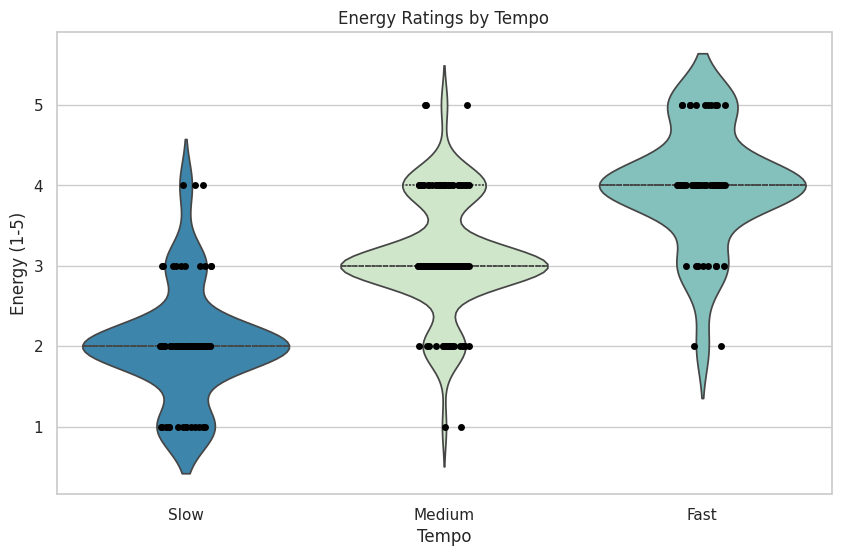

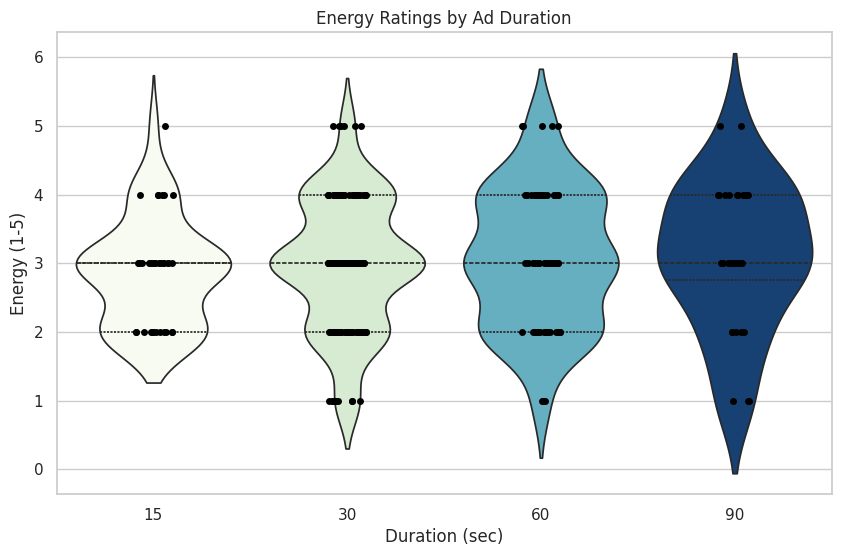

In [104]:
# Creating violin plot with strip plot for `energy_1_5` vs `mood`
plt.figure(figsize = (10, 6))
sns.violinplot(
    x = 'mood',
    y = 'energy_1_5',
    data = ads_df,
    hue = 'mood',
    palette = 'GnBu',
    dodge = False,
    inner = 'quartile'
)
sns.stripplot(
    x='mood',
    y='energy_1_5',
    data=ads_df,
    color='black',
    size=5,
    jitter=True,
    dodge=False
)
plt.legend([], [], frameon = False)
plt.title('Energy Ratings by Mood')
plt.xlabel('Mood')
plt.ylabel('Energy (1-5)')
plt.show()

# 2. Creating violin plot with strip plot for `energy_1_5` vs `tempo`
print("\n")
plt.figure(figsize = (10, 6))
sns.violinplot(
    x = 'tempo',
    y = 'energy_1_5',
    data = ads_df,
    hue = 'tempo',
    palette = 'GnBu',
    order = ['Slow', 'Medium', 'Fast'],
    dodge = False,
    inner = 'quartile'
)
sns.stripplot(
    x = 'tempo',
    y = 'energy_1_5',
    data = ads_df,
    color = 'black',
    size = 5,
    jitter = True,
    dodge = False
)
plt.legend([], [], frameon = False)
plt.title('Energy Ratings by Tempo')
plt.xlabel('Tempo')
plt.ylabel('Energy (1-5)')
plt.show()

# 3. Creating violin plot with strip plot for `energy_1_5` vs `duration_sec`
print("\n")
plt.figure(figsize = (10, 6))
sns.violinplot(
    x = 'duration_sec',
    y = 'energy_1_5',
    data = ads_df,
    hue = 'duration_sec',
    palette = 'GnBu',
    order = [15, 30, 60, 90],
    dodge = False,
    inner = 'quartile'
)
sns.stripplot(
    x = 'duration_sec',
    y = 'energy_1_5',
    data = ads_df,
    color = 'black',
    size = 5,
    jitter = True,
    dodge = False
)
plt.legend([], [], frameon = False)
plt.title('Energy Ratings by Ad Duration')
plt.xlabel('Duration (sec)')
plt.ylabel('Energy (1-5)')
plt.show()


### Saving current Dataframe

In [105]:
# Creating save path
save_path = local_dir + '/ads_df_post_eda.csv'

# Saving to CSV
ads_df_post_eda = ads_df.copy()
csv_filename = "ads_df_post_eda.csv"
ads_df_post_eda.to_csv(save_path, index = False)
print(f"Saved CSV to {local_dir + '/ads_df_post_eda.csv'}")

Saved CSV to /content/drive/MyDrive/SPRING 2026/DATASCI 210/Capstone/Data/ADS/ads_df_post_eda.csv
